In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [5]:
# extract
path = "data/academia_redfit.csv"
df = pd.read_csv(path)
display(df.head(15))

df.info()

,idade,sexo,frequencia_semanal_treino,tipo_atividade,tempo_medio_exercicio,minutos_totais_semana,preco_plano,possui_nutricionista,primeiro_PGC,ultimo_PGC,data_matricula,estado
0,48,Outro,7.0,Natação,45.3,317.1,188.47,Não,39.5,24.9,2021-07-28,Ativa
1,30,Outro,7.0,Yoga,98.1,686.7,198.07,Não,25.2,23.5,2020-12-28,Ativa
2,35,Masculino,5.0,Cardio,33.9,169.5,154.90,Não,27.2,11.4,2022-02-27,Ativa
3,43,Outro,3.0,Yoga,75.6,226.8,250.79,Sim,14.4,19.2,2022-12-01,Ativa
4,37,Masculino,0.0,CrossFit,114.0,0.0,168.02,Sim,21.5,18.1,2024-01-20,Sedentária
5,57,Masculino,2.0,Yoga,95.5,191.0,74.06,Não,35.8,14.4,2020-04-26,Ativa
6,55,Masculino,7.0,CrossFit,95.7,669.9,289.13,Sim,16.1,14.9,2022-06-12,Ativa
7,21,Feminino,5.0,Yoga,117.5,587.5,259.55,Não,13.2,13.5,2021-09-07,Ativa
8,37,Masculino,7.0,Yoga,NaN,NaN,194.34,Sim,18.4,21.8,2025-09-02,Ativa
9,50,Masculino,1.0,Musculação,105.0,105.0,290.91,Sim,37.3,31.0,2020-05-06,Ativa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   idade                      1000 non-null   int64  
 1   sexo                       1000 non-null   object 
 2   frequencia_semanal_treino  949 non-null    float64
 3   tipo_atividade             1000 non-null   object 
 4   tempo_medio_exercicio      954 non-null    float64
 5   minutos_totais_semana      905 non-null    float64
 6   preco_plano                1000 non-null   float64
 7   possui_nutricionista       1000 non-null   object 
 8   primeiro_PGC               1000 non-null   float64
 9   ultimo_PGC                 1000 non-null   float64
 10  data_matricula             1000 non-null   object 
 11  estado                     1000 non-null   object 
dtypes: float64(6), int64(1), object(5)
memory usage: 93.9+ KB


In [ ]:
# Transform
df_tratando = df.copy()

df_tratando['evolucao_pgc'] = df_tratando['primeiro_PGC'] - df_tratando['ultimo_PGC']

## Calcula a média da coluna e preencher os nulos com a media

df_tratando['frequencia_semanal_treino'] = df_tratando['frequencia_semanal_treino'].fillna(df_tratando['frequencia_semanal_treino'].mean())

df_tratando['tempo_medio_exercicio'] = df['tempo_medio_exercicio'].fillna(df['tempo_medio_exercicio'].median())

df_tratando['minutos_totais_semana'] = df_tratando['frequencia_semanal_treino'] * df_tratando['tempo_medio_exercicio']

display(df_tratando.info())

## Padronizando os dados
cols_str = ['sexo', 'tipo_atividade', 'estado', 'possui_nutricionista']
for col in cols_str:
    df_tratando[col] = df_tratando[col].str.strip().str.title()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   idade                      1000 non-null   int64  
 1   sexo                       1000 non-null   object 
 2   frequencia_semanal_treino  1000 non-null   float64
 3   tipo_atividade             1000 non-null   object 
 4   tempo_medio_exercicio      1000 non-null   float64
 5   minutos_totais_semana      1000 non-null   float64
 6   preco_plano                1000 non-null   float64
 7   possui_nutricionista       1000 non-null   object 
 8   primeiro_PGC               1000 non-null   float64
 9   ultimo_PGC                 1000 non-null   float64
 10  data_matricula             1000 non-null   object 
 11  estado                     1000 non-null   object 
 12  evolucao_pgc               1000 non-null   float64
dtypes: float64(7), int64(1), object(5)
memory usage: 

None

In [10]:

df_tratando['evolucao_pgc'] = df_tratando['evolucao_pgc'].round(1)
df_tratando['evolucao_pgc'] = df_tratando['evolucao_pgc'].apply(lambda x: float(f"{x:.1f}"))
df_tratando['minutos_totais_semana'] = df_tratando['minutos_totais_semana'].apply(lambda x: float(f"{x:.1f}"))
df_tratando['frequencia_semanal_treino'] = df_tratando['frequencia_semanal_treino'].apply(lambda x: float(f"{x:.1f}"))

df_tratando.to_csv('data/academia_redfit_limpo.csv', index=False)

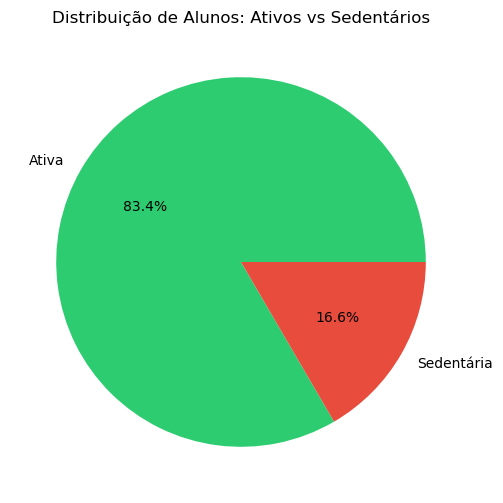

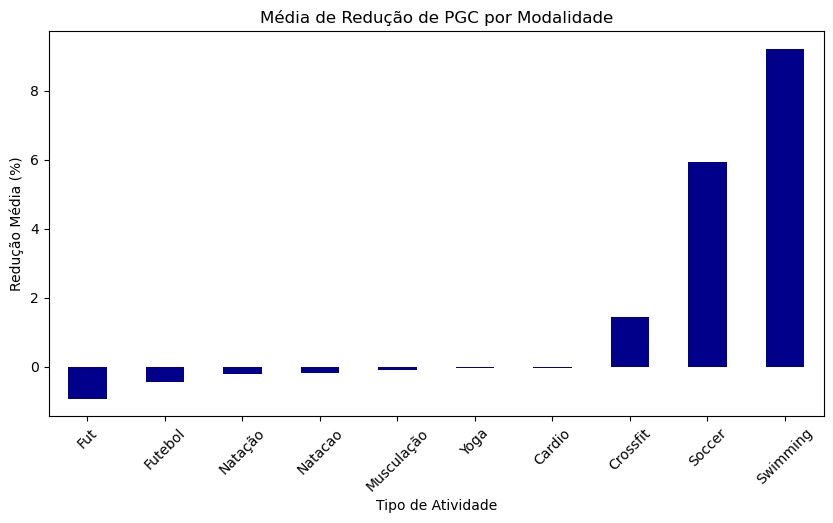

In [11]:
# Gráfico de Pizza

plt.figure(figsize=(8, 6))
contagem_estado = df_tratando['estado'].value_counts()
plt.pie(contagem_estado, labels=contagem_estado.index, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
plt.title('Distribuição de Alunos: Ativos vs Sedentários')
plt.show()

 # Gráfico de Barras 
 
plt.figure(figsize=(10, 5))


df_tratando.groupby('tipo_atividade')['evolucao_pgc'].mean().sort_values().plot(kind='bar', color='darkblue')
plt.title('Média de Redução de PGC por Modalidade')
plt.ylabel('Redução Média (%)')
plt.xlabel('Tipo de Atividade')
plt.xticks(rotation=45)
plt.show()

In [12]:
# MACHINE LEARNING

df_tratando['sexo_n'] = df_tratando['sexo'].map({'Masculino': 0, 'Feminino': 1, 'Outro': 2})
df_tratando['estado_n'] = df_tratando['estado'].map({'Ativa': 1, 'Sedentária': 0})

X = df_tratando[['idade', 'frequencia_semanal_treino', 'tempo_medio_exercicio', 'evolucao_pgc']]
y = df_tratando['estado_n']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_academia = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_academia.fit(X_train, y_train)

# RESULTADOS
previsoes = modelo_academia.predict(X_test)
print("Relatório de Performance do Modelo")
print(classification_report(y_test, previsoes))

Relatório de Performance do Modelo
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       1.00      1.00      1.00       164

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

